# Perseus Works — Wikidata Type Distributions

Top 20 values for `instance_of`, `genre`, and `form_of_creative_work` in `perseus_works_wikidata.tsv`.
Cells are comma-separated, so values are split and exploded before counting.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline
plt.rcParams['figure.dpi'] = 150

INPUT_TSV = Path('../data/perseus_works_wikidata.tsv')

df = pd.read_csv(INPUT_TSV, sep='\t')
print(f'Total works (rows): {len(df)}')

Total works (rows): 1084


In [2]:
def top_counts(column, n=20):
    exploded = (
        df[column]
        .dropna()
        .astype(str)
        .str.split(',')
        .explode()
        .str.strip()
    )
    exploded = exploded[exploded != '']
    return exploded.value_counts().head(n)

panels = [
    ('instance_of', 'Top 20 \u2014 Instance Of'),
    ('genre', 'Top 20 \u2014 Genre'),
    ('form_of_creative_work', 'Top 20 \u2014 Form of Creative Work'),
]

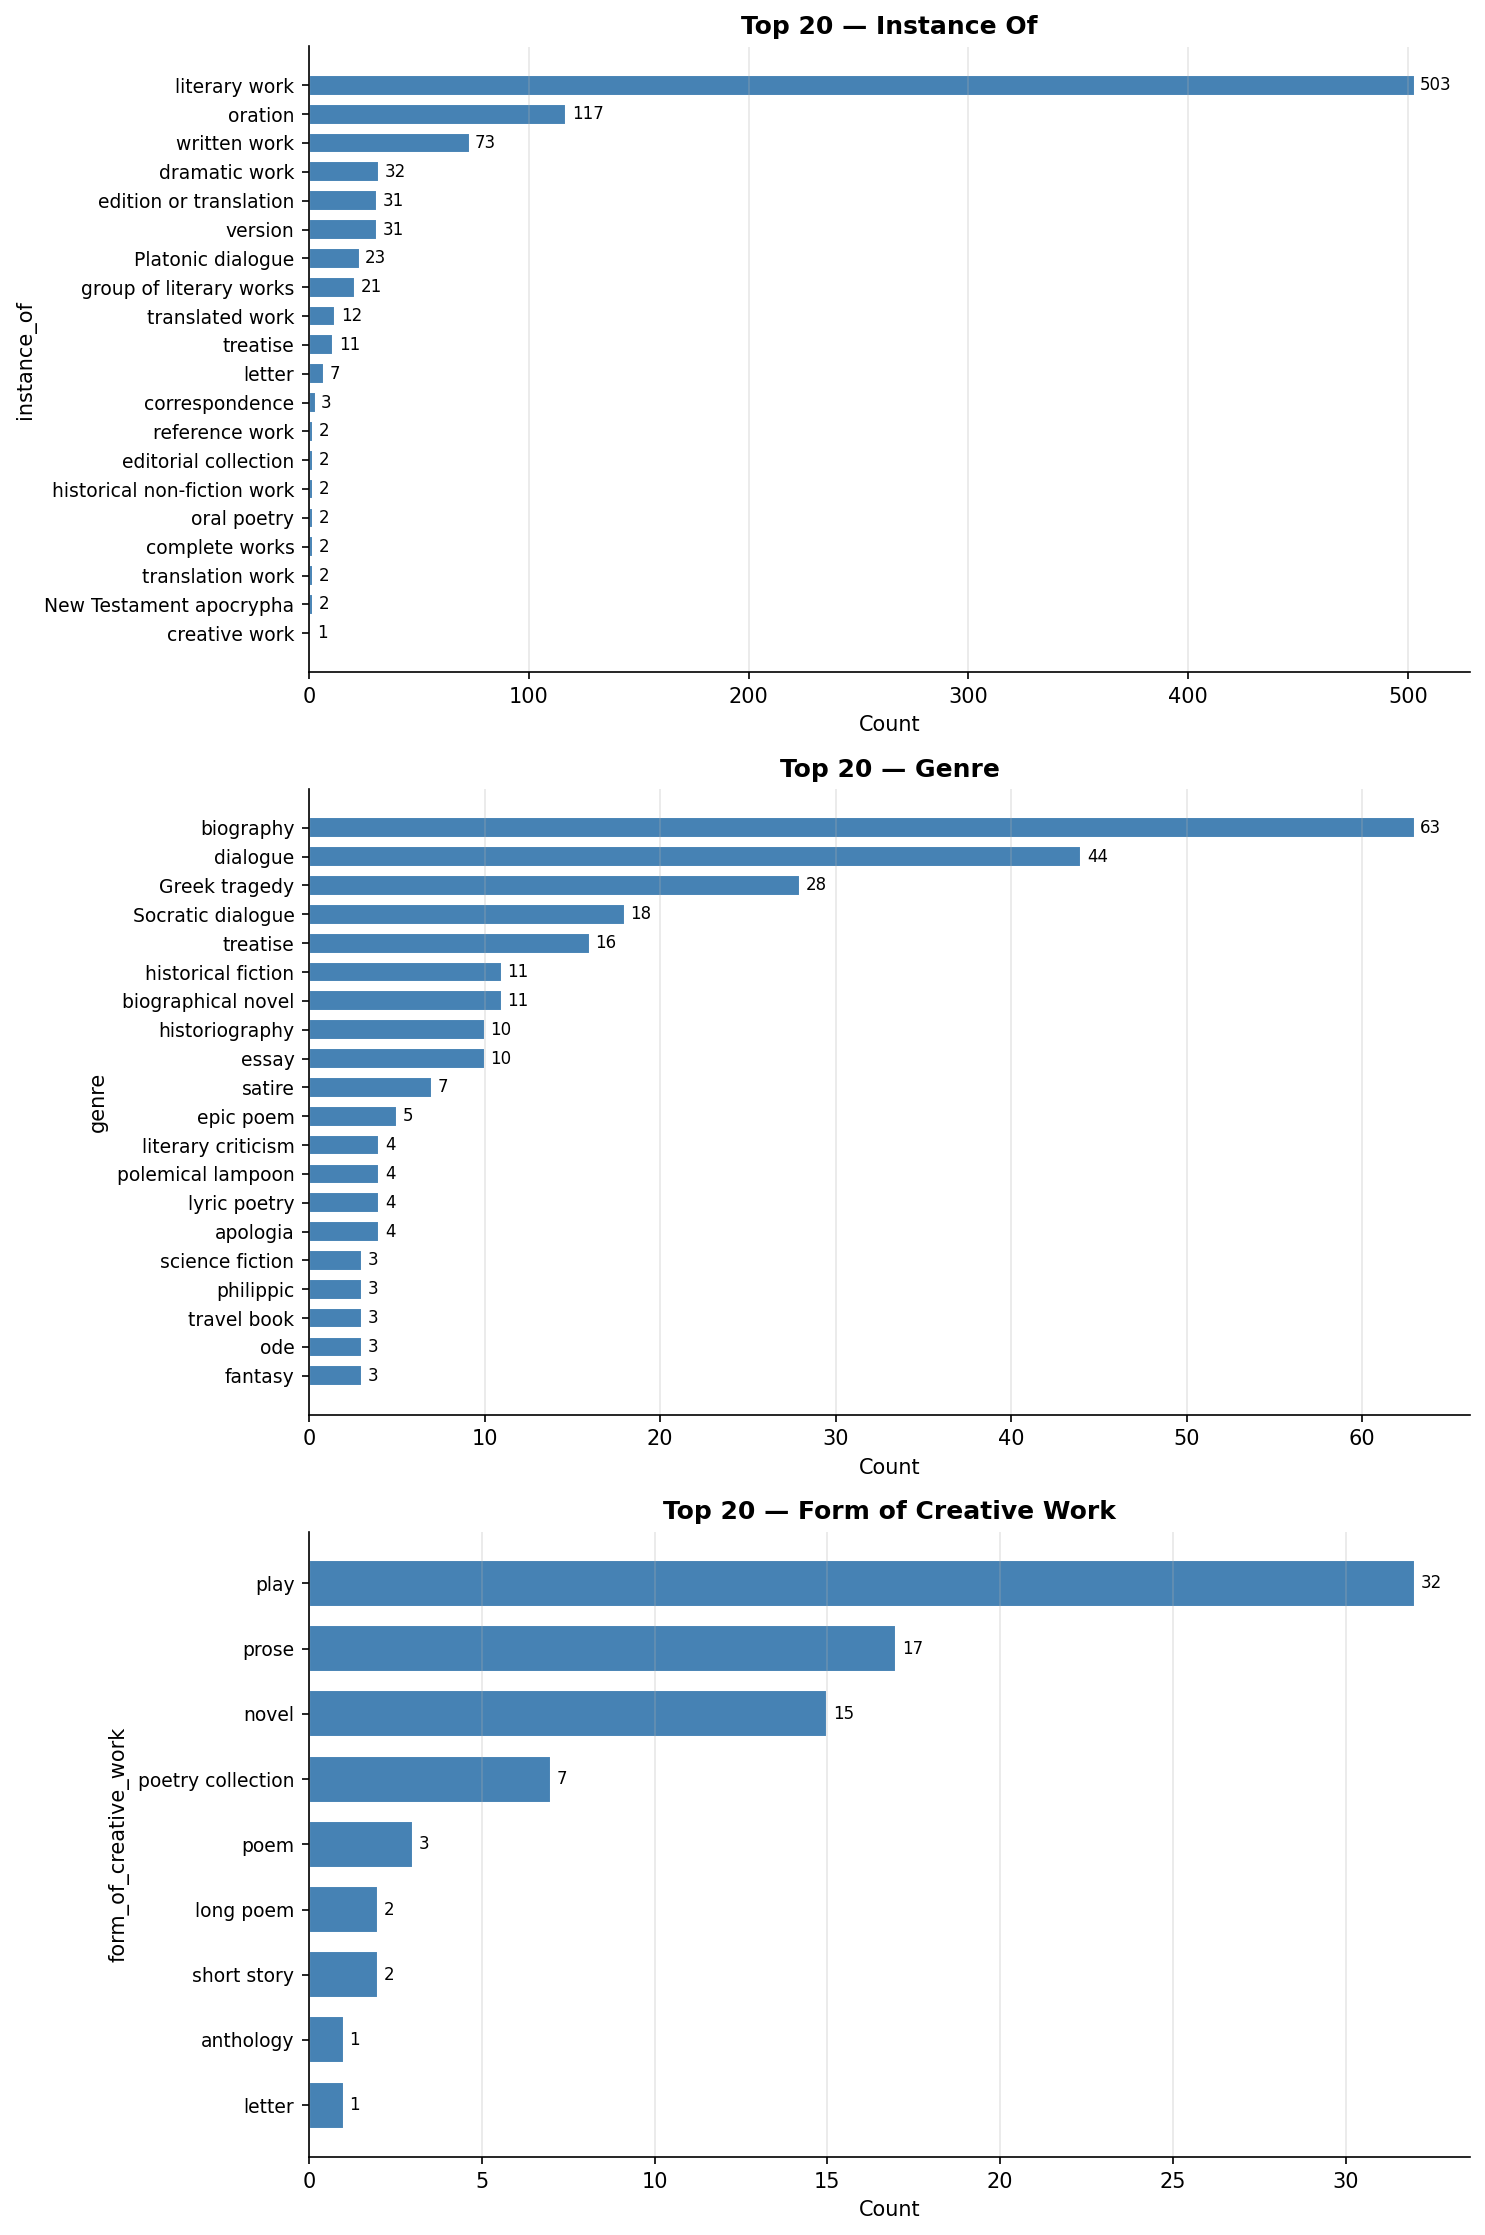

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
for ax, (col, title) in zip(axes, panels):
    counts = top_counts(col)
    ax.barh(range(len(counts)), counts.values, color='steelblue',
            edgecolor='white', height=0.72)
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(counts.index, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Count')
    ax.set_ylabel(col)
    ax.set_title(title, fontsize=12, fontweight='600')
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for i, v in enumerate(counts.values):
        ax.text(v + max(counts.values) * 0.005, i, str(int(v)),
                va='center', fontsize=8)
plt.tight_layout()
plt.show()